<a href="https://colab.research.google.com/github/nuranferhan/ML-projects/blob/main/House%20Prices/House_Prices_%5BML_Steps%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **House Prices - with ML Steps**

# Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load Data

Load the training and testing datasets and read the data_description.txt file for understanding feature definitions.

In [ ]:
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')
data_description_path = '/content/data_description.txt'

# Load and display data description for reference
with open(data_description_path, 'r') as file:
   data_description = file.read()
print("Data Description:\n")
print(data_description[:500], "...\n")  # Display the first 500 characters

Data Description:

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Uni ...



* Training data includes the target variable SalePrice.
* Test data is used for final prediction submissions.

# Step 2: Data Cleaning

In [ ]:
# Drop columns with excessive missing values
cols_to_drop = ["Alley", "FireplaceQu", "PoolQC", "Fence", "MiscFeature"]
train.drop(columns=cols_to_drop, inplace=True)
test.drop(columns=cols_to_drop, inplace=True)

# Fill missing values
for df in [train, test]:
   # Numerical columns
   num_cols = df.select_dtypes(include=["float64", "int64"]).columns
   df[num_cols] = df[num_cols].fillna(df[num_cols].median())

   # Categorical columns
   cat_cols = df.select_dtypes(include=["object"]).columns
   df[cat_cols] = df[cat_cols].fillna("NA")

* Columns with excessive missing values (e.g., Alley, FireplaceQu) are dropped.
* Missing numerical values are filled with the median to avoid bias.
* Categorical missing values are replaced with "NA" for consistent encoding.

# Step 3: Feature Engineering and Selection

Enhance the dataset by creating new features that capture critical patterns.

In [ ]:
# Create meaningful features based on domain knowledge
def add_features(df):
   df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
   df['TotalBathrooms'] = (df['FullBath'] + df['HalfBath'] * 0.5 +
                           df['BsmtFullBath'] + df['BsmtHalfBath'] * 0.5)
   df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] +
                         df['3SsnPorch'] + df['ScreenPorch'])
   df['Age'] = df['YrSold'] - df['YearBuilt']
   df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

add_features(train)
add_features(test)

* **TotalSF:** Total square footage, combining basement and floor areas.
* **TotalBathrooms:** Sum of all bathrooms, accounting for full and half baths.
* **TotalPorchSF:** Total porch area, summing open, enclosed, and screened porches.
* **Age:** Time since the house was built.
* **RemodAge:** Time since the house was last remodeled.

These features encapsulate housing characteristics crucial for price prediction.

# Step 4: Data Visualization

Analyze relationships between features and SalePrice visually.

- Shows that prices are right-skewed, indicating the need for potential log transformation.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


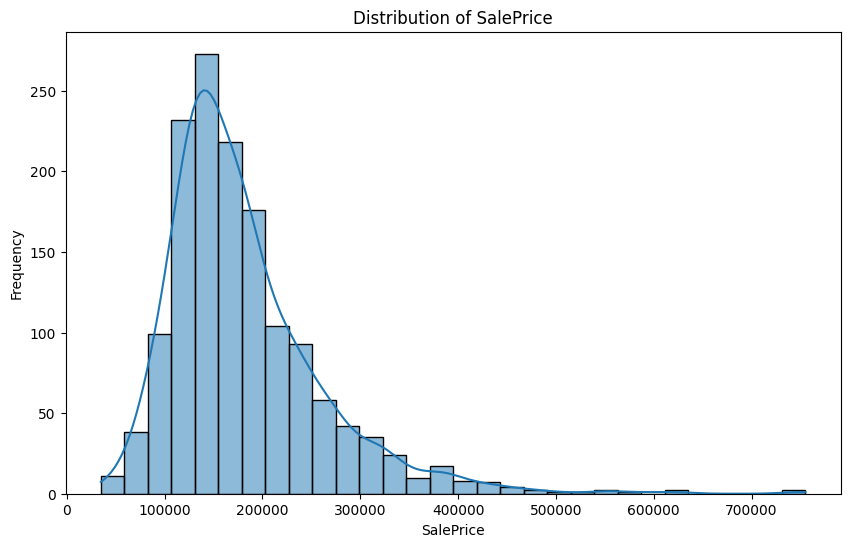

In [ ]:
# Distribution of SalePrice
plt.figure(figsize=(10, 6))
sns.histplot(train['SalePrice'], kde=True, bins=30)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()

* Highlights numerical features highly correlated with SalePrice (e.g., GrLivArea, OverallQual).

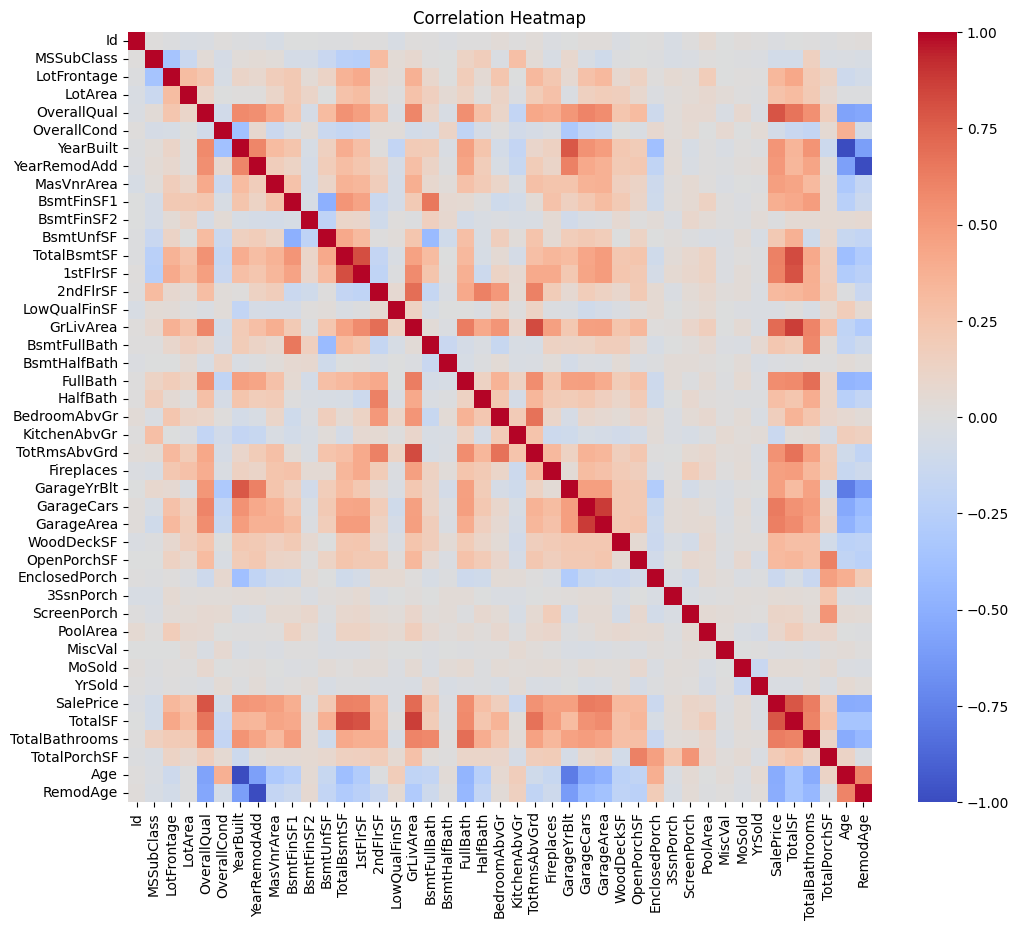

In [ ]:
# Correlation heatmap for numerical columns only
plt.figure(figsize=(12, 10))
numerical_train = train.select_dtypes(include=["float64", "int64"])
correlation_matrix = numerical_train.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

* Demonstrates how OverallQual significantly influences house prices.

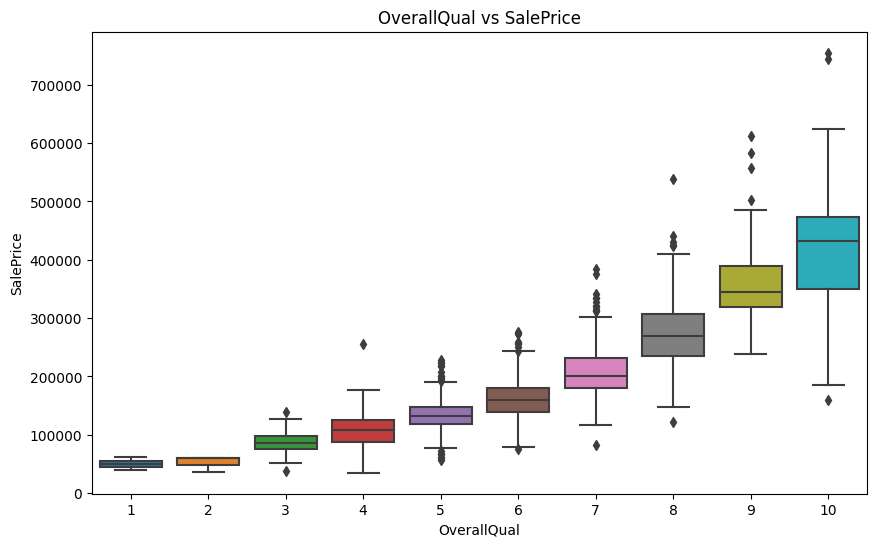

In [ ]:
# Boxplot: OverallQual vs SalePrice
plt.figure(figsize=(10, 6))
sns.boxplot(x=train['OverallQual'], y=train['SalePrice'])
plt.title('OverallQual vs SalePrice')
plt.xlabel('OverallQual')
plt.ylabel('SalePrice')
plt.show()

# Step 5: Preprocessing

Prepare data for model training.

Separate target variable (SalePrice) from features.

Identify categorical and numerical columns.

Apply preprocessing:
* Scale numerical features to normalize ranges.
* Encode categorical features using one-hot encoding.

In [ ]:
# Separate target variable and features
y = train['SalePrice']
X = train.drop(columns=['SalePrice', 'Id'])
test_ids = test['Id']
test.drop(columns=['Id'], inplace=True)

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns

# Define preprocessors
preprocessor = ColumnTransformer(
   transformers=[
       ('num', MinMaxScaler(), numerical_cols),
       ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
   ])

# Step 6: Model Training with Random Forest

Train a Random Forest model as a baseline.

**Pipeline:**
* Combines preprocessing and modeling for a streamlined workflow.

**Validation:**
* The dataset is split into training and validation sets.
* RMSE (Root Mean Squared Error) is used to measure model performance.

In [ ]:
rf_model = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', RandomForestRegressor(random_state=42))])

# Split the training data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model
rf_model.fit(X_train, y_train)

# Evaluate the model
val_preds = rf_model.predict(X_val)
rf_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
print(f"Random Forest RMSE: {rf_rmse}")

Random Forest RMSE: 29231.556119944104


# Step 7: Model Evaluation

Compare Random Forest with Gradient Boosting (XGBoost).


In [ ]:
# Train Gradient Boosting (XGBoost)
xgb_model = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', XGBRegressor(random_state=42))])
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_val)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_preds))
print(f"XGBoost RMSE: {xgb_rmse}")

XGBoost RMSE: 28903.02764184726


**Results:**
* Random Forest and XGBoost models are trained and evaluated on the validation set.
* RMSE values highlight performance differences, guiding model selection.

# Step 8: Model Optimization (Optional hyperparameter tuning)

Enhance model performance through hyperparameter tuning.


In [ ]:
param_grid = {
   'model__n_estimators': [100, 200],
   'model__max_depth': [3, 5],
}
gs = GridSearchCV(rf_model, param_grid, cv=3, scoring='neg_mean_squared_error')
gs.fit(X_train, y_train)
print(f"Best Params: {gs.best_params_}")

Best Params: {'model__max_depth': 5, 'model__n_estimators': 200}


* Use GridSearchCV to optimize parameters (e.g., n_estimators, max_depth).
* Identify the best parameter combination for the Random Forest model.

# Step 9: Predictions and Submission

Generate predictions for the test dataset.

* Apply the best-tuned model to the preprocessed test data.
* Save predictions in the required submission format.


In [ ]:
final_preds = gs.best_estimator_.predict(test)
submission = pd.DataFrame({'Id': test_ids, 'SalePrice': final_preds})
submission.to_csv('submission.csv', index=False)